In [ ]:
image_path = '/home/emanmunir/detection/image (2).png'
image = Image.open(image_path).convert("RGB")
image

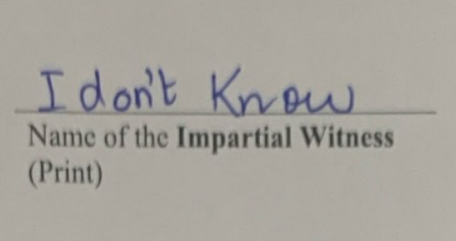

In [1]:
from PIL import Image
image_path = '/home/emanmunir/abark/signature_detection/image (1).png'
image = Image.open(image_path).convert("RGB")
image

## **TROCR Handwritten OCR** 

In [28]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/home/emanmunir/detection/myenv/lib/python3.10/site-packages/transformers/generation/utils.py:1249: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


output 0 0


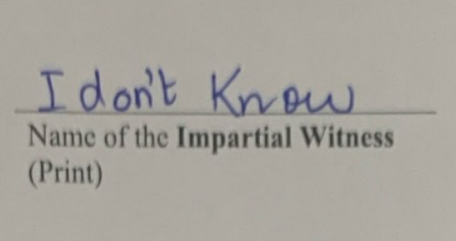

In [30]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("output",generated_text)
image



## **EASYOCR**

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Text: Idonl, Probability: 0.363916197681536
Text: KnA, Probability: 0.40318118096967126
Text: Name of thc Impartial Witness, Probability: 0.6962422298052853
Text: (Print), Probability: 0.9821139567695915


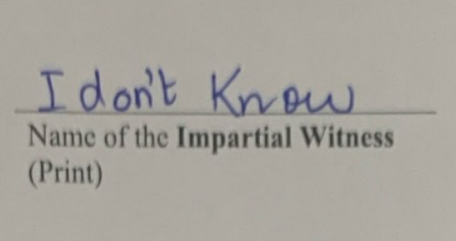

In [4]:
import easyocr

# Initialize the reader with the desired language(s)
reader = easyocr.Reader(['en'])


# Perform OCR on the image
results = reader.readtext(image_path)

# Print the results
for (bbox, text, prob) in results:
    print(f'Text: {text}, Probability: {prob}')

image


## **OCR DONUT**

In [32]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-to-text", model="jinhybr/OCR-Donut-CORD")

[{'generated_text': '<s_cord-v2><s_menu><s_nm> Idont</s_nm><s_price> KnzQu</s_nm><s_price> Idont</s_price><sep/><s_nm> Name ofthc Impertial Witness (Print)</s_nm><s_price> WnesS</s_nm><s_price>'}]


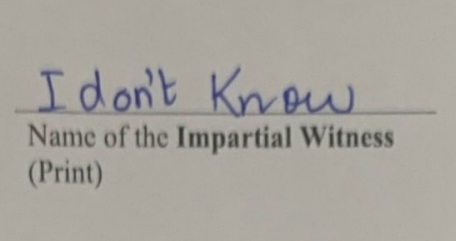

In [33]:
from PIL import Image

# Load your image  # Change this path to your image file path
image = Image.open(image_path)

# Use the pipeline to get text from the image
result = pipe(image)

# Print the result
print(result)
image

## **PyTesseract OCR**

Name of the Impartial Witness
(Print)



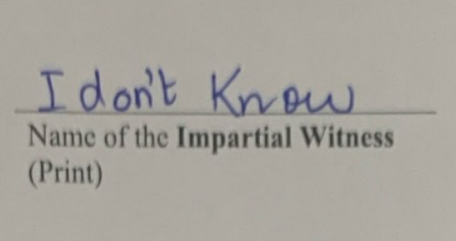

In [3]:
import pytesseract
from PIL import Image



text = pytesseract.image_to_string(image)

print(text)
image


In [2]:
from google.cloud import vision

# Create a client
client = vision.ImageAnnotatorClient()
import os

# Set the path to the service account key
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/home/emanmunir/abark/signature_detection/google_credentials.json'

# Load the image into memory
with open(image_path, 'rb') as image_file:
    content = image_file.read()
    image = vision.Image(content=content)

# Performs label detection on the image file
response = client.text_detection(image=image)
texts = response.text_annotations

print('Texts:')
for text in texts:
    print('\n"{}"'.format(text.description))

if response.error.message:
    raise Exception('{}\nFor more info on error messages, check: https://cloud.google.com/apis/design/errors'.format(response.error.message))


ModuleNotFoundError: No module named 'google.cloud'